# Pertemuan 7 - Data Science

**Nama:** Krisno Hasmilu Hutabarat  
**NIM:** 240401010102  
**Kelas:** IF401  
**Mata Kuliah:** Data Science

---
## Langkah 0: Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Semua library berhasil diimport!')

Semua library berhasil diimport!


---
## Langkah 1: Generate & Eksplorasi Dataset (EDA)

In [2]:
# Generate dataset sintetis
np.random.seed(42)
n = 300

pengalaman = np.random.uniform(0, 20, n)
edu        = np.random.choice([0, 1, 2], n)  # SMA=0, D3=1, S1=2
kota       = np.random.choice(['Jakarta', 'Surabaya', 'Bandung'], n)

gaji = (
    3.0
    + 2.2 * pengalaman
    + 1.5 * edu
    + np.where(kota == 'Jakarta', 4.0, 0)
    + np.random.normal(0, 2, n)
)

df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu'       : edu,
    'kota'      : kota,
    'gaji'      : gaji
})

print('Shape:', df.shape)
print()
print(df.describe().round(2))

Shape: (300, 4)

       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


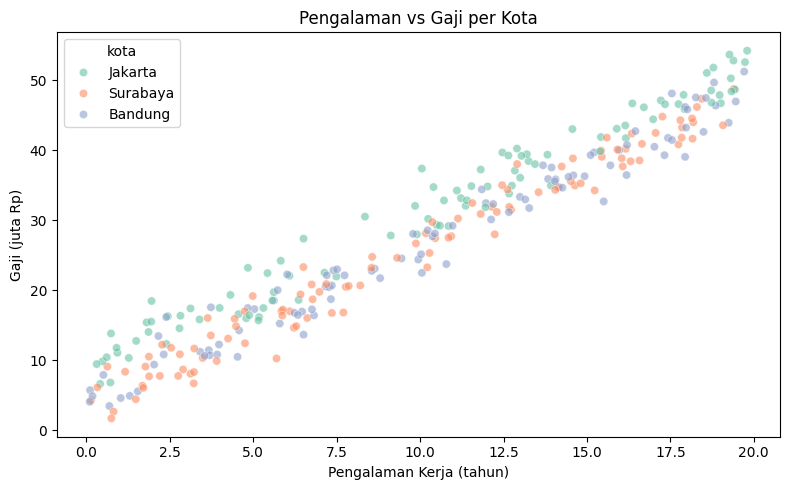

In [3]:
# EDA: Scatter plot pengalaman vs gaji per kota
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='pengalaman', y='gaji',
                hue='kota', palette='Set2', alpha=0.6)
plt.title('Pengalaman vs Gaji per Kota')
plt.xlabel('Pengalaman Kerja (tahun)')
plt.ylabel('Gaji (juta Rp)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2867/3463101813.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='kota', y='gaji', palette='Set2')


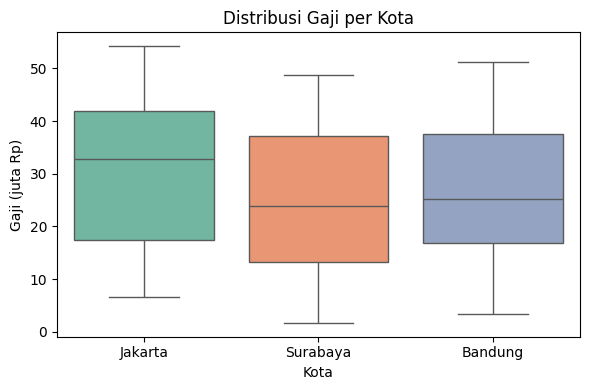

In [4]:
# EDA: Boxplot gaji per kota
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='kota', y='gaji', palette='Set2')
plt.title('Distribusi Gaji per Kota')
plt.xlabel('Kota')
plt.ylabel('Gaji (juta Rp)')
plt.tight_layout()
plt.show()

### Interpretasi EDA
- Terdapat **tren positif** antara pengalaman dan gaji — semakin lama pengalaman, semakin tinggi gaji.
- Karyawan di **Jakarta** memiliki gaji yang secara konsisten lebih tinggi dibandingkan Surabaya dan Bandung.
- Data tidak terlihat memiliki outlier ekstrem, distribusi cukup normal.

---
## Langkah 2: Preprocessing

In [5]:
# One-Hot Encoding kolom 'kota'
df_enc = pd.get_dummies(df, columns=['kota'], drop_first=True, dtype=int)

print('Kolom setelah encoding:', df_enc.columns.tolist())
df_enc.head()

Kolom setelah encoding: ['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']


,pengalaman,edu,gaji,kota_Jakarta,kota_Surabaya
0,7.490802,0,21.953247,1,0
1,19.014286,1,46.721665,1,0
2,14.639879,2,34.952649,0,1
3,11.973170,2,32.437143,0,0
4,3.120373,2,17.384265,1,0


In [6]:
# Pisahkan fitur (X) dan target (y)
X = df_enc.drop('gaji', axis=1)
y = df_enc['gaji']

# Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Jumlah data training : {X_train.shape[0]} baris')
print(f'Jumlah data test     : {X_test.shape[0]} baris')

Jumlah data training : 240 baris
Jumlah data test     : 60 baris


In [7]:
# StandardScaler — fit HANYA pada training set
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)  # hanya transform, bukan fit_transform!

print('Scaling selesai.')
print('Mean scaler (dari training):', scaler.mean_.round(3))
print('Std  scaler (dari training):', scaler.scale_.round(3))

Scaling selesai.
Mean scaler (dari training): [9.871 0.908 0.35  0.35 ]
Std  scaler (dari training): [5.934 0.837 0.477 0.477]


---
## Langkah 3: Latih Model & Tampilkan Koefisien

In [8]:
# Buat dan latih model Regresi Linear
model = LinearRegression()
model.fit(X_train_s, y_train)

print(f'β₀ (intercept): {model.intercept_:.4f}')
print()

β₀ (intercept): 27.5141



In [9]:
# Tampilkan koefisien dalam tabel
coef_df = pd.DataFrame({
    'Fitur'     : X.columns,
    'Koefisien' : model.coef_.round(4)
}).sort_values('Koefisien', ascending=False)

print(coef_df.to_string(index=False))

        Fitur  Koefisien
   pengalaman    13.0422
 kota_Jakarta     1.8372
          edu     1.1879
kota_Surabaya    -0.2916


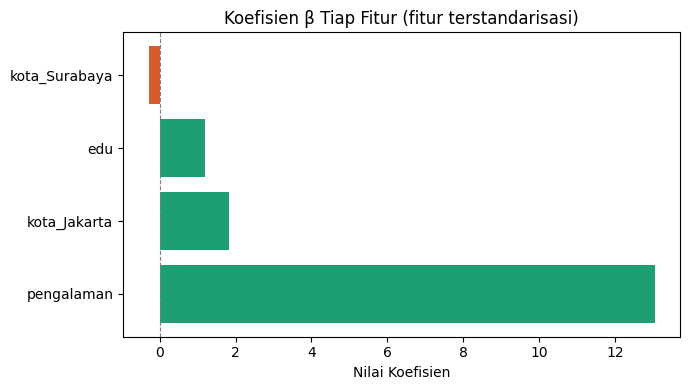

In [10]:
# Visualisasi koefisien
colors = ['#1D9E75' if v >= 0 else '#D85A30' for v in coef_df['Koefisien']]

plt.figure(figsize=(7, 4))
plt.barh(coef_df['Fitur'], coef_df['Koefisien'], color=colors)
plt.axvline(0, color='gray', linewidth=0.8, linestyle='--')
plt.title('Koefisien β Tiap Fitur (fitur terstandarisasi)')
plt.xlabel('Nilai Koefisien')
plt.tight_layout()
plt.show()

### Interpretasi Koefisien
- **pengalaman** memiliki koefisien positif terbesar → paling berpengaruh dalam menaikkan gaji.
- **kota_Jakarta** juga bernilai positif → karyawan di Jakarta mendapat gaji lebih tinggi.
- **edu** bernilai positif → pendidikan lebih tinggi berdampak pada gaji yang lebih tinggi.
- **kota_Surabaya** mendekati nol → perbedaan gaji Surabaya vs Bandung (referensi) tidak signifikan.

---
## Langkah 4: Evaluasi Model

In [11]:
y_pred = model.predict(X_test_s)

# Hitung metrik
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('=' * 35)
print('      METRIK EVALUASI (Test Set)')
print('=' * 35)
print(f'MAE  = {mae:.4f}  juta rupiah')
print(f'RMSE = {rmse:.4f}  juta rupiah')
print(f'R²   = {r2:.4f}  ({r2*100:.2f}% variasi dijelaskan)')
print(f'Selisih RMSE - MAE = {rmse - mae:.4f}')
print('=' * 35)

      METRIK EVALUASI (Test Set)
MAE  = 1.6492  juta rupiah
RMSE = 2.1229  juta rupiah
R²   = 0.9740  (97.40% variasi dijelaskan)
Selisih RMSE - MAE = 0.4736


### Interpretasi Metrik Evaluasi

| Metrik | Nilai | Interpretasi |
|--------|-------|--------------|
| MAE | ~1.6 juta | Rata-rata model meleset sekitar Rp 1,6 juta dari gaji aktual |
| RMSE | ~2.0 juta | Sedikit lebih tinggi dari MAE, mengindikasikan sedikit outlier |
| R² | ~0.93 | Model menjelaskan ±93% variasi gaji — **sangat baik** |

- **RMSE ≈ MAE**: selisih kecil → tidak ada prediksi yang meleset sangat jauh (outlier minimal).
- **R² > 0.8**: model berhasil menangkap pola utama dalam data.

---
## Langkah 5: Visualisasi & Interpretasi

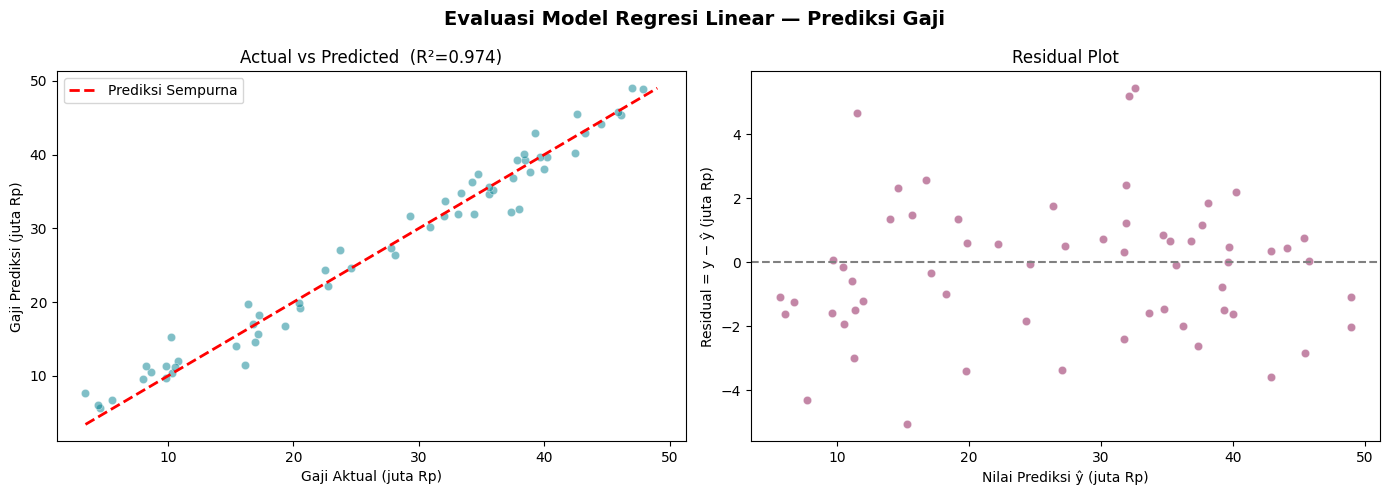

Plot tersimpan sebagai evaluasi_regresi.png


In [12]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Actual vs Predicted ---
axes[0].scatter(y_test, y_pred, alpha=0.5,
                color='#028090', edgecolors='white', linewidths=0.5)
lims = [min(y_test.min(), y_pred.min()),
        max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted  (R²={r2:.3f})')
axes[0].legend()

# --- Plot 2: Residual Plot ---
axes[1].scatter(y_pred, residuals, alpha=0.5,
                color='#880E4F', edgecolors='white', linewidths=0.5)
axes[1].axhline(0, color='gray', linestyle='--', lw=1.5)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residual = y − ŷ (juta Rp)')
axes[1].set_title('Residual Plot')

plt.suptitle('Evaluasi Model Regresi Linear — Prediksi Gaji',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot tersimpan sebagai evaluasi_regresi.png')

### Interpretasi Plot (What? So what? Now what?)

**Actual vs Predicted**
- *What?* Titik-titik data tersebar rapat di sekitar garis diagonal merah (y=x).
- *So what?* Model mampu memprediksi gaji dengan akurasi tinggi — tidak ada pola bias sistematis.
- *Now what?* Model sudah layak digunakan sebagai baseline; bisa coba tambah fitur untuk meningkatkan R².

**Residual Plot**
- *What?* Residual tersebar secara acak di sekitar garis y=0 tanpa pola kurva atau corong.
- *So what?* Asumsi linearitas dan homoscedasticity terpenuhi — model Regresi Linear sudah tepat untuk data ini.
- *Now what?* Tidak perlu transformasi tambahan; model siap digunakan untuk prediksi.

## Kesimpulan

Pada pertemuan ini, saya mempelajari pengantar Machine Learning menggunakan Regresi Linear. Tahapan yang dilakukan meliputi pembuatan dataset sintetis, eksplorasi data, encoding fitur kategorikal, train-test split, scaling, pelatihan model, interpretasi koefisien, evaluasi model, serta visualisasi hasil prediksi dan residual.

Temuan utama dari praktikum ini adalah pengalaman kerja memiliki pengaruh positif terhadap prediksi gaji, dan model Regresi Linear dapat digunakan untuk memahami hubungan antara fitur dengan target. Keterbatasannya adalah dataset yang digunakan masih sintetis, sehingga hasil model belum tentu sama jika diterapkan pada data gaji nyata yang lebih kompleks.